# `LagrangeEquations_package` demo

In this demo, we will demonstrate some capabilities of the `LagrangeEquations_package` for solving advanced problems via Euler-Lagrange equations.

Exercises adapted from:

Morin, David. 2008. *Introduction to Classical Mechanics: With Problems and Solutions*. Cambridge: Cambridge University Press.

### Problem: Pendulum with a free support 

Problem 16, p. 221

> A mass $M$ is free to slide along a frictionless rail. A pendulum of length $\ell$ and mass $m$ hangs from $M$ (see Figure). Find the equations of motion

### Solution

![Pendulum_free_suspension.png](https://i.postimg.cc/4dNCyz2Z/Pendulum_free_suspension.png)

Analyzing the problem, we can obtain kinetic energy $K$ and potential energy $V$:


$K = \dfrac{1}{2}M\dot{x}^2 + \dfrac{1}{2}m\left(\dot{x}^2 + \ell^2\dot{\theta}^2 + 2\ell\dot{x}\dot{\theta}\cos\theta\right)$

$V = mgl\cos\theta$

The transformation used for $m$ coordinates is:

$(x, y)_m =  (x + \ell \sin\theta,\,-\ell \cos\theta)$

## Lagrange Equations

In [1]:
# Loading LagrangeEquations_package.sage
url_lagrange_eqs =  'https://raw.githubusercontent.com/JupyterPER/SageApps/refs/heads/main/LagrangeEquations_package.sage'
load(url_lagrange_eqs)

The package was successfully loaded!!!


In [2]:
url_show_package = 'https://raw.githubusercontent.com/JupyterPER/SageApps/refs/heads/main/Show_package.sage'
load(url_show_package)

The package was successfully loaded!!!


In [3]:
# parameters
m, M, l, g, t = var('m, M, l, g, t')

# quantities as functions of time
x = function('x')(t)
th = function('theta')(t)

# derivatives
dxdt(t) = diff(x,t)
dthdt(t) = diff(th,t)

# potential energy
V = - m*g*l*cos(th)

# kinetic energy
T = 1/2*M*dxdt(t)^2 + 1/2*m*(dxdt(t)^2 + l^2*dthdt(t)^2 + 2*l*dxdt(t)*dthdt(t)*cos(th))

In [4]:
print('Potential energy:\n')
Show(V)
print('\n'+20*'-'+'\n')
print('Kinetic energy:\n')
Show(T)

Potential energy:



\(-g l m \cos\left({\theta}\right)\)


--------------------

Kinetic energy:



\(\dfrac{1}{2} \, M {\dot{x}}^{2} + \dfrac{1}{2} \, {\left({\dot{\theta}}^{2} l^{2} + 2 \, {\dot{\theta}} {\dot{x}} l \cos\left({\theta}\right) + {\dot{x}}^{2}\right)} m\)

In [5]:
# Lagrange equations
LE = LagrangeEqs(T, V, x, th)

In [6]:
# display LE
for le in list(LE.items()):
    le_list = list(le)
    Show(le_list)

# or use Show(LE[x]), Show(LE[th])

\(\left[{x}, 0 = M {\ddot{x}} - {\left({\dot{\theta}}^{2} l \sin\left({\theta}\right) - {\ddot{\theta}} l \cos\left({\theta}\right) - {\ddot{x}}\right)} m\right]\)

\(\left[{\theta}, -{\dot{\theta}} {\dot{x}} l m \sin\left({\theta}\right) - g l m \sin\left({\theta}\right) = -{\left({\dot{\theta}} {\dot{x}} l \sin\left({\theta}\right) - {\ddot{\theta}} l^{2} - {\ddot{x}} l \cos\left({\theta}\right)\right)} m\right]\)

When using `desolve_odeint`, the goal is to rewrite `LE`s as a system of $n$ 2nd order ODE into system of $2n$ 1st order ODE in such standardized form:

$ v_{x} = \dot{x}$

$ a_{x} (= \ddot{x}) = f_1(x, \theta, v_{x}, v_{\theta})$

$v_{\theta} = \dot{\theta}$

$a_{\theta} ( = \ddot{\theta} ) = f_2(x, \theta, v_{x}, v_{\theta})$

The equations can be rewritten by solving for the acceleration explicitly.

In [7]:
# there is LE_standardize_raw routine which returns standardized LEqs and a lot of other stuff
# 1st is dictionary of rhs of DEs in standardized form (a list since it may be possible to have more forms sometimes?)
# 2nd is dictionary of dvars, 3rd is list of free parameters, 4th is dictionary of substitutions
# LE_standardize_raw is not intended for ordinary usage

LE_st_raw = LE_standardize_raw(LE)
for item in LE_st_raw:
    # default show works, Show may lag when displaying dictionaries
    show(item)

[{x(t): [x__d,
   -(l*m*theta__d^2*sin(theta__) + g*m*cos(theta__)*sin(theta__))/(m*cos(theta__)^2 - M - m)],
  theta(t): [theta__d,
   (l*m*theta__d^2*cos(theta__)*sin(theta__) + (M*g + g*m)*sin(theta__))/(l*m*cos(theta__)^2 - M*l - l*m)]}]

{x(t): [x__, x__d], theta(t): [theta__, theta__d]}

[M, m, l, g]

{diff(x(t), t, t): x__dd,
 diff(x(t), t): x__d,
 x(t): x__,
 diff(theta(t), t, t): theta__dd,
 diff(theta(t), t): theta__d,
 theta(t): theta__}

---

## Automatic preparation of LEs

In [8]:
# there is more convenient LE_standardize, which returns only rhs of LEs and dependent variables
# these two can be directly fed into desolve_odeint

LE_standard = LE_standardize(LE)
LE_system = LE_standard[0] 
LE_dvars = LE_standard[1] 

Show(LE_system)
Show(LE_dvars)

\(\left[{\dot{x}}, -\dfrac{l m {\dot{\theta}}^{2} \sin\left({\theta}\right) + g m \cos\left({\theta}\right) \sin\left({\theta}\right)}{m \cos\left({\theta}\right)^{2} - M - m}, {\dot{\theta}}, \dfrac{l m {\dot{\theta}}^{2} \cos\left({\theta}\right) \sin\left({\theta}\right) + {\left(M g + g m\right)} \sin\left({\theta}\right)}{l m \cos\left({\theta}\right)^{2} - M l - l m}\right]\)

\(\left[{x}, {\dot{x}}, {\theta}, {\dot{\theta}}\right]\)

---

In [9]:
# LE_standardize generates global variables with double underscores 
# if you want to further manipulate DEs or dvars (in rare ocassions)

# symbolic variables for x(t) and th(t)
show(x__, theta__)

x__ theta__

In [10]:
# derivatives
show(x__d, theta__d, x__dd, theta__dd)

x__d theta__d x__dd theta__dd

## Numerical solution of LEs

In [11]:
# list of parameters for substitution
params = [m == 1, M == 2, l == 0.5, g == 9.81] 

EqS_vals = lambda params: [eq.subs(params) for eq in LE_system]

ics = [0.5, -0.1, 10*pi/180, 0]

# time grid - times from 0 s to 10 s with a time step of 0.01 s
dt, tk = 0.01, 10
t_vals = [0, 0+dt, .. , tk]

# solution
sol = desolve_odeint(EqS_vals(params), ics, t_vals, LE_dvars, ivar=t)

# display the first 10 rows of the solution
sol[:10, :]

array([[ 0.5       , -0.1       ,  0.17453293,  0.        ],
       [ 0.49904131, -0.09173988,  0.17428125, -0.05032306],
       [ 0.49816514, -0.08349976,  0.17352691, -0.10051095],
       [ 0.49737118, -0.07529968,  0.17227194, -0.15042861],
       [ 0.49665894, -0.06715977,  0.17051969, -0.1999412 ],
       [ 0.49602772, -0.05910027,  0.16827491, -0.24891428],
       [ 0.4954766 , -0.05114156,  0.16554365, -0.29721393],
       [ 0.49500448, -0.04330418,  0.16233332, -0.34470692],
       [ 0.49461004, -0.03560883,  0.15865264, -0.39126092],
       [ 0.49429176, -0.02807639,  0.15451167, -0.43674472]])

## Displaying trajectory

In [12]:
# transformations into cartesian coordinates
to_x_c = lambda x_val, th_val: x_val + l.subs(params)*sin(th_val)
to_y_c = lambda th_val: - l.subs(params)*cos(th_val)

In [13]:
# recalculation of coordinates into cartesian x_c, y_c
x_vals = sol[:,0]
th_vals = sol[:,2]

x_c = to_x_c(x_vals, th_vals)
y_c = to_y_c(th_vals)

sol_x_c_y_c = list(zip(x_c, y_c))
# test
sol_x_c_y_c[0]

(0.586824088833465, -0.492403876506104)

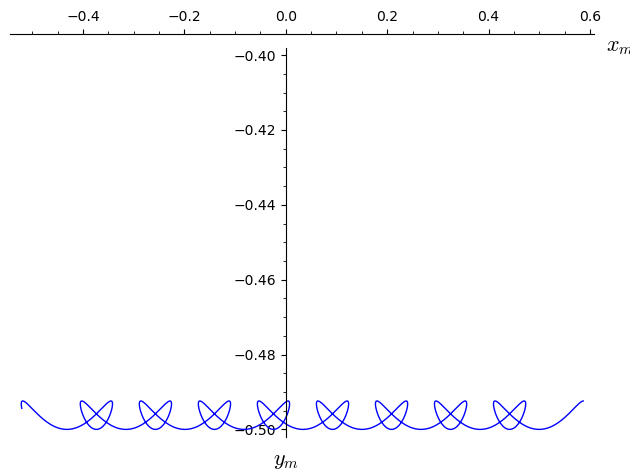

In [14]:
# trajectory of mass m
line(sol_x_c_y_c, axes_labels=['$x_m$','$y_m$'],ymax=-0.40)

# Problem: Pendulum with support on an inclined plane

Problem 17 (pp. 221)

> A mass  $M$ is free to slide down a frictionless plane inclined at angle $\beta$. A pendulum of length $\ell$ and mass $m$ hangs from $M$ (see Fig). Find the equations of motion.

## Solution

[![Pendulum_inclined_plane.png](https://i.postimg.cc/d1tM38Nw/Pendulum_inclined_plane.png)](https://postimg.cc/cKjk58Nb)

For this system on an inclined plane, the kinetic and potential energies are:

$T=\frac12 M \dot z^2+\frac12 m\left(\dot z^2+\ell^2\dot\theta^2+2\ell \dot z\dot\theta\cos(\theta+\beta)\right)$

$V=-Mgz\sin\beta-mg\left(z\sin\beta+\ell\cos\theta\right)$

The Lagrangian for this system is:

$
L=
\frac12 M \dot z^2
+\frac12 m\left(\dot z^2+\ell^2\dot\theta^2+2\ell \dot z\dot\theta\cos(\theta+\beta)\right)
+Mgz\sin\beta
+mg\left(z\sin\beta+\ell\cos\theta\right).
$

The transformations used for $m$ and $M$ coordinates are:

$(x,y)_M = (z \cos\beta,\,-z \sin\beta),$

$(x,y)_m = (z \cos\beta + \ell \sin\theta,\,-z \sin\beta - \ell \cos\theta)$

In [15]:
# parameters
m, M, l, g, beta, t = var('m, M, l, g, beta, t')

# quantities as functions of time
z  = function('z')(t)
th = function('theta')(t)

# derivatives
dzdt(t)  = diff(z, t)
dthdt(t) = diff(th, t)

# potential energy
V = -M*g*z*sin(beta) - m*g*(z*sin(beta) + l*cos(th))

# kinetic energy
T = 1/2*M*dzdt(t)^2 + 1/2*m*(dzdt(t)^2 + l^2*dthdt(t)^2 + 2*l*dzdt(t)*dthdt(t)*cos(th + beta))

In [16]:
Show(V)

\(-M g {z} \sin\left(\beta\right) - {\left(l \cos\left({\theta}\right) + {z} \sin\left(\beta\right)\right)} g m\)

In [17]:
Show(T)

\(\dfrac{1}{2} \, M {\dot{z}}^{2} + \dfrac{1}{2} \, {\left({\dot{\theta}}^{2} l^{2} + 2 \, {\dot{\theta}} {\dot{z}} l \cos\left(\beta + {\theta}\right) + {\dot{z}}^{2}\right)} m\)

In [18]:
# Lagrange equations
LE = LagrangeEqs(T, V, z, th)
Show(LE[z])

\(M g \sin\left(\beta\right) + g m \sin\left(\beta\right) = M {\ddot{z}} - {\left({\dot{\theta}}^{2} l \sin\left(\beta + {\theta}\right) - {\ddot{\theta}} l \cos\left(\beta + {\theta}\right) - {\ddot{z}}\right)} m\)

In [19]:
Show(LE[th])

\(-{\dot{\theta}} {\dot{z}} l m \sin\left(\beta + {\theta}\right) - g l m \sin\left({\theta}\right) = -{\left({\dot{\theta}} {\dot{z}} l \sin\left(\beta + {\theta}\right) - {\ddot{\theta}} l^{2} - {\ddot{z}} l \cos\left(\beta + {\theta}\right)\right)} m\)

In [20]:
# standardized LEs
LE_standard = LE_standardize(LE)
LE_system = LE_standard[0] 
LE_dvars = LE_standard[1] 

show(LE_system)
show(LE_dvars)

[z__d,
 -(l*m*theta__d^2*sin(beta + theta__) + g*m*cos(beta + theta__)*sin(theta__) + M*g*sin(beta) + g*m*sin(beta))/(m*cos(beta + theta__)^2 - M - m),
 theta__d,
 (l*m*theta__d^2*cos(beta + theta__)*sin(beta + theta__) + M*g*sin(theta__) + g*m*sin(theta__) + (M*g*sin(beta) + g*m*sin(beta))*cos(beta + theta__))/(l*m*cos(beta + theta__)^2 - M*l - l*m)]

[z__, z__d, theta__, theta__d]

In [21]:
# list of parameters for substitution

EqS_vals = lambda params: list(vector(LE_system).subs(params))
params = [m == 1, M == 2, l == 0.5, g == 9.81, beta == 20*pi/180]

ics = [0, -0.1, 90*pi/180, 0]

# time grid - times from 0 s to 10 s with a time step of 0.01 s
dt, tk = 0.01, 5
t_vals = [0, 0+dt, .. , tk]

# solution
sol = desolve_odeint(EqS_vals(params), ics, t_vals, LE_dvars, ivar=t)

# display the first 10 rows of the solution
sol[:10, :]

array([[ 0.00000000e+00, -1.00000000e-01,  1.57079633e+00,
         0.00000000e+00],
       [-8.83557084e-04, -7.66985808e-02,  1.56989495e+00,
        -1.80274054e-01],
       [-1.53345727e-03, -5.32428760e-02,  1.56719093e+00,
        -3.60521772e-01],
       [-1.94738484e-03, -2.94782542e-02,  1.56268468e+00,
        -5.40717952e-01],
       [-2.12147506e-03, -5.24946690e-03,  1.55637682e+00,
        -7.20839762e-01],
       [-2.05030635e-03,  1.95996466e-02,  1.54826820e+00,
        -9.00867978e-01],
       [-1.72688988e-03,  4.52264159e-02,  1.53835982e+00,
        -1.08078835e+00],
       [-1.14265676e-03,  7.17895571e-02,  1.52665282e+00,
        -1.26059307e+00],
       [-2.87443262e-04,  9.94493482e-02,  1.51314834e+00,
        -1.44028244e+00],
       [ 8.50525492e-04,  1.28367756e-01,  1.49784752e+00,
        -1.61986661e+00]])

In [22]:
to_x_M = lambda z_val: z_val*cos(beta.subs(params))
to_y_M = lambda z_val: -z_val*sin(beta.subs(params))

to_x_m = lambda z_val, th_val: z_val*cos(beta.subs(params)) + l.subs(params)*sin(th_val)
to_y_m = lambda z_val, th_val: -z_val*sin(beta.subs(params)) - l.subs(params)*cos(th_val)

z_vals = sol[:,0]
th_vals = sol[:,2]

x_c_m = to_x_m(z_vals, th_vals)
y_c_m = to_y_m(z_vals, th_vals)

In [23]:
sol_x_c_y_c_m = list(zip(x_c_m, y_c_m))

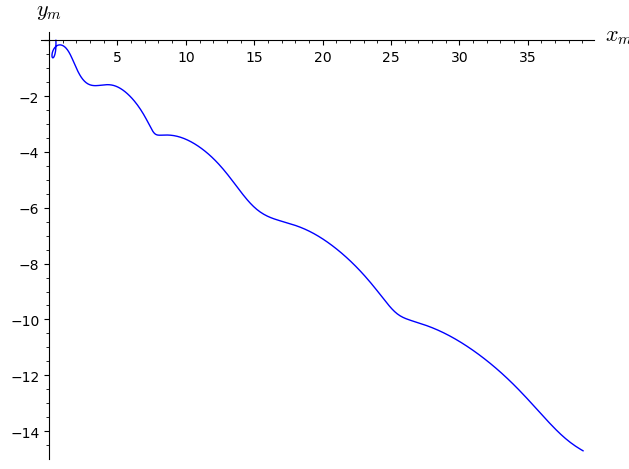

In [24]:
line(sol_x_c_y_c_m,  axes_labels=['$x_m$','$y_m$'],ymax=0)